<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/202501_Doe_DCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseños Completos Aleatorizados (DCA)**
# **Escribe el Nombre del Curso: Diseño de Experimentos**
## **Escribe tu nombre completo**
> Email:

> Celular:

> Código Estudiantil

# **Librerias para Trabar en R**

In [1]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [2]:
# @title **Librerias para Trabar en Colab**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import scipy.stats as stats

<a name="inicio"></a>


## **1.** [Problema del fabricante de calzado](#T1)
## **2.** [Visualizando el DataFrame](#T2)

## **3.** [BoxPlot para el DCA](#T3)

## **4.** [Análisis de Varianza (ANOVA)](#T4)

## **5.** [Resumen del Análisis de Varianza](#T5)

## **6.** [Comparaciones Múltiples - Desgaste](#T6)

## **7.** [Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'](#T7)


## **8.** [Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples](#T8)

## **9.** [HSD de Tukey Grafico para la diferencia de Medias](#T9)


## **10.** [HSD de Tukey Grafico Vertical para la diferencia de Medias](#T10)

## **11.** [Shapiro Wilks para Desgaste en R y Python](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Problema del fabricante de calzado**
### *Problema: Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva. La suela de los zapatos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérrdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independiente de las demás. Los datos (en mg) sobre el desgaste de cada tipo de cuero se muestran en la tabla siguiente:*

In [3]:
data = {'Tipos de Cuero': ['A'] * 6 + ['B'] * 6 + ['C'] * 6 + ['D'] * 6,
        'Desgaste': [264, 260, 258, 241, 262, 255,
                     208, 220, 216, 200, 213, 206,
                     220, 263, 219, 225, 230, 228,
                     217, 226, 215, 224, 220, 222]}

df = pd.DataFrame(data)
display(df)

,Tipos de Cuero,Desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [15]:
%%R
# Create the data in R
Tipos_de_Cuero <- rep(c('A', 'B', 'C', 'D'), each = 6)
Desgaste <- c(264, 260, 258, 241, 262, 255,
              208, 220, 216, 200, 213, 206,
              220, 263, 219, 225, 230, 228,
              217, 226, 215, 224, 220, 222)

# Create the dataframe in R
df_r <- data.frame(Tipos_de_Cuero, Desgaste)

# Display the dataframe
print(df_r)

   Tipos_de_Cuero Desgaste
1               A      264
2               A      260
3               A      258
4               A      241
5               A      262
6               A      255
7               B      208
8               B      220
9               B      216
10              B      200
11              B      213
12              B      206
13              C      220
14              C      263
15              C      219
16              C      225
17              C      230
18              C      228
19              D      217
20              D      226
21              D      215
22              D      224
23              D      220
24              D      222


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Visualizando el DataFrame**


In [4]:
display(df)

,Tipos de Cuero,Desgaste
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. BoxPlot para el DCA**


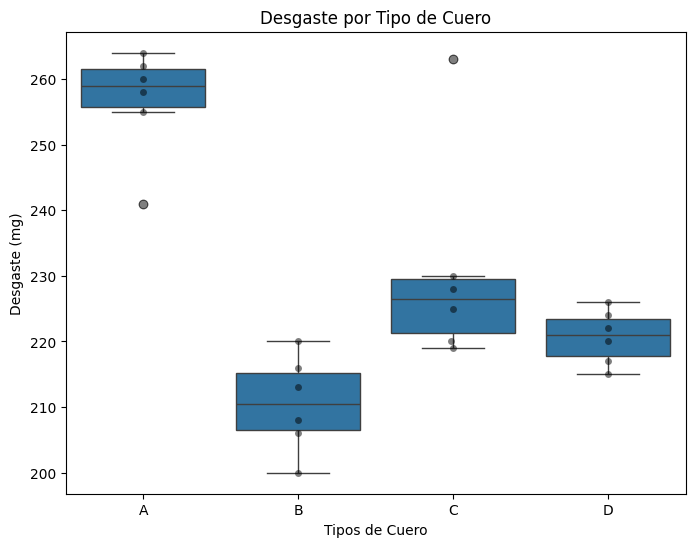

In [5]:
# @title **3. BoxPlot para el DCA**
plt.figure(figsize=(8, 6))
sns.boxplot(x="Tipos de Cuero", y="Desgaste", data=df)
sns.swarmplot(x="Tipos de Cuero", y="Desgaste", data=df, color='black', alpha=0.5)
plt.title('Desgaste por Tipo de Cuero')
plt.xlabel('Tipos de Cuero')
plt.ylabel('Desgaste (mg)')
plt.show()

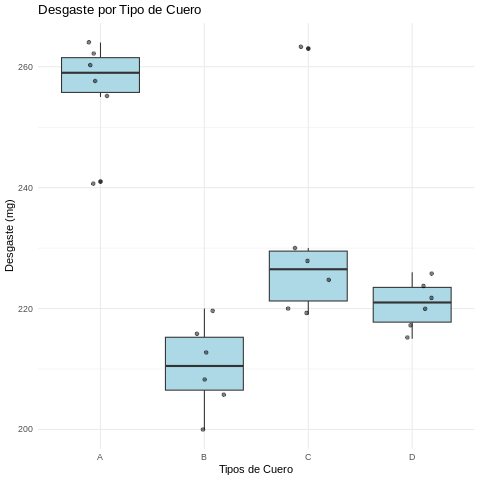

In [16]:
%%R
# @title **3. BoxPlot para el DCA en R**
library(ggplot2)

# Create the boxplot with swarmplot overlay
ggplot(df_r, aes(x = Tipos_de_Cuero, y = Desgaste)) +
  geom_boxplot(fill = "lightblue") + # Add boxplot with fill color
  geom_jitter(width = 0.2, color = "black", alpha = 0.5) + # Add swarmplot (jittered points)
  labs(title = "Desgaste por Tipo de Cuero",
       x = "Tipos de Cuero",
       y = "Desgaste (mg)") +
  theme_minimal() # Use a minimal theme

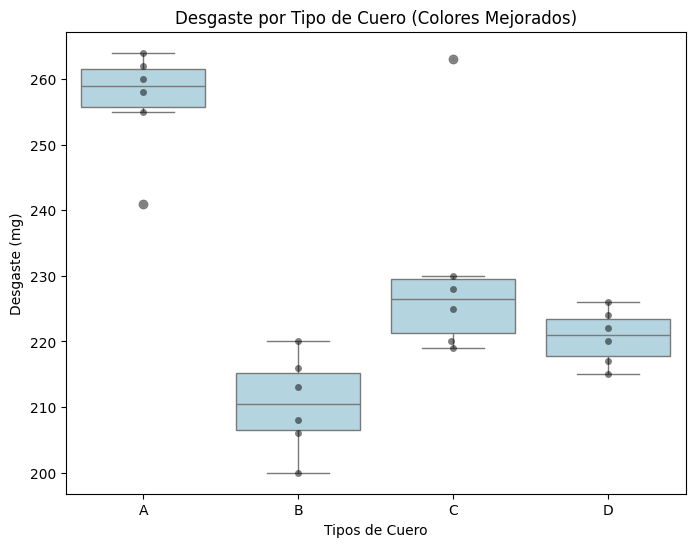

In [6]:
# @title **4. BoxPlot para el Desgaste - Mejorando colores**
plt.figure(figsize=(8, 6))
sns.boxplot(x="Tipos de Cuero", y="Desgaste", data=df, color='lightblue')  # Cambiar color de las cajas
sns.swarmplot(x="Tipos de Cuero", y="Desgaste", data=df, color='black', alpha=0.5)
plt.title('Desgaste por Tipo de Cuero (Colores Mejorados)')
plt.xlabel('Tipos de Cuero')
plt.ylabel('Desgaste (mg)')
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Análisis de Varianza (ANOVA)**


In [7]:
# @title **Análisis de Varianza (ANOVA)**
modelo_desgaste = ols("Desgaste ~ Q('Tipos de Cuero')", data=df).fit()
anova_desgaste = sm.stats.anova_lm(modelo_desgaste, typ=1)
print(anova_desgaste)

                       df       sum_sq      mean_sq          F    PR(>F)
Q('Tipos de Cuero')   3.0  7072.333333  2357.444444  23.237501  0.000001
Residual             20.0  2029.000000   101.450000        NaN       NaN


In [17]:
%%R
# @title **Análisis de Varianza (ANOVA) en R**
# Perform ANOVA
anova_result <- aov(Desgaste ~ Tipos_de_Cuero, data = df_r)

# Print ANOVA summary
summary(anova_result)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [8]:
# @title **6. Análisis de Varianza Tipo II**
# Realizar el ANOVA
model = ols('Desgaste ~ Q("Tipos de Cuero")', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
print(anova_table)

                       df       sum_sq      mean_sq          F    PR(>F)
Q("Tipos de Cuero")   3.0  7072.333333  2357.444444  23.237501  0.000001
Residual             20.0  2029.000000   101.450000        NaN       NaN


In [18]:
%%R
# @title **6. Análisis de Varianza Tipo I en R**
# Perform ANOVA Type I
anova_result_type1 <- aov(Desgaste ~ Tipos_de_Cuero, data = df_r)

# Print ANOVA summary
summary(anova_result_type1)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Resumen del Análisis de Varianza**




In [9]:
# @title **Resumen del Análisis de Varianza**

print(modelo_desgaste.summary())

                            OLS Regression Results                            
Dep. Variable:               Desgaste   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     23.24
Date:                Sat, 06 Sep 2025   Prob (F-statistic):           1.00e-06
Time:                        12:42:53   Log-Likelihood:                -87.301
No. Observations:                  24   AIC:                             182.6
Df Residuals:                      20   BIC:                             187.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [19]:
%%R
# @title **Resumen del Análisis de Varianza en R**

# Print ANOVA summary
summary(anova_result)

               Df Sum Sq Mean Sq F value Pr(>F)    
Tipos_de_Cuero  3   7072  2357.4   23.24  1e-06 ***
Residuals      20   2029   101.4                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Comparaciones Múltiples - Desgaste**


In [10]:
# @title **Comparaciones Múltiples - Desgaste**

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['Desgaste'], groups=df['Tipos de Cuero'], alpha=0.05)

# Print the results
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0 -62.4431 -29.8903   True
     A      C -25.8333 0.0013 -42.1097  -9.5569   True
     A      D    -36.0    0.0 -52.2764 -19.7236   True
     B      C  20.3333 0.0112   4.0569  36.6097   True
     B      D  10.1667 0.3263  -6.1097  26.4431  False
     C      D -10.1667 0.3263 -26.4431   6.1097  False
------------------------------------------------------


In [20]:
%%R
# @title **Comparaciones Múltiples - Desgaste en R**
# Perform Tukey's HSD post-hoc test
tukey_result_r <- TukeyHSD(anova_result)

# Print the results
print(tukey_result_r)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Desgaste ~ Tipos_de_Cuero, data = df_r)

$Tipos_de_Cuero
         diff        lwr        upr     p adj
B-A -46.16667 -62.443068 -29.890265 0.0000007
C-A -25.83333 -42.109735  -9.556932 0.0013189
D-A -36.00000 -52.276401 -19.723599 0.0000265
C-B  20.33333   4.056932  36.609735 0.0112174
D-B  10.16667  -6.109735  26.443068 0.3263417
D-C -10.16667 -26.443068   6.109735 0.3263417



[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'**




In [11]:
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero'**
print('Desgaste por Tipos de Cuero')
display(df.groupby('Tipos de Cuero')['Desgaste'].agg(['mean', 'std', 'median', 'count']))

Desgaste por Tipos de Cuero


,mean,std,median,count
Tipos de Cuero,,,,
A,256.666667,8.286535,259.0,6
B,210.500000,7.259477,210.5,6
C,230.833333,16.339115,226.5,6
D,220.666667,4.179314,221.0,6


In [21]:
%%R
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' en R**
library(dplyr)

df_r %>%
  group_by(Tipos_de_Cuero) %>%
  summarise(
    mean = mean(Desgaste),
    std = sd(Desgaste),
    median = median(Desgaste),
    count = n()
  )

# A tibble: 4 × 5
  Tipos_de_Cuero  mean   std median count
  <chr>          <dbl> <dbl>  <dbl> <int>
1 A               257.  8.29   259      6
2 B               210.  7.26   210.     6
3 C               231. 16.3    226.     6
4 D               221.  4.18   221      6



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples**

In [12]:
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples**

print('Desgaste por Tipos de Cuero')
display(df.groupby('Tipos de Cuero')['Desgaste'].agg(['mean', 'std', 'median', 'count']))

print("\nTukey's HSD Post-Hoc Test Results:")
print(tukey_result)

Desgaste por Tipos de Cuero


,mean,std,median,count
Tipos de Cuero,,,,
A,256.666667,8.286535,259.0,6
B,210.500000,7.259477,210.5,6
C,230.833333,16.339115,226.5,6
D,220.666667,4.179314,221.0,6



Tukey's HSD Post-Hoc Test Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B -46.1667    0.0 -62.4431 -29.8903   True
     A      C -25.8333 0.0013 -42.1097  -9.5569   True
     A      D    -36.0    0.0 -52.2764 -19.7236   True
     B      C  20.3333 0.0112   4.0569  36.6097   True
     B      D  10.1667 0.3263  -6.1097  26.4431  False
     C      D -10.1667 0.3263 -26.4431   6.1097  False
------------------------------------------------------


In [22]:
%%R
# @title **Descriptores numéricos para 'Desgaste' por 'Tipos de Cuero' con Comparaciones Múltiples en R**
library(dplyr)

print("Desgaste por Tipos de Cuero:")
df_r %>%
  group_by(Tipos_de_Cuero) %>%
  summarise(
    mean = mean(Desgaste),
    std = sd(Desgaste),
    median = median(Desgaste),
    count = n()
  ) %>%
  print()

print("\nTukey's HSD Post-Hoc Test Results:")
tukey_result_r <- TukeyHSD(anova_result)
print(tukey_result_r)

[1] "Desgaste por Tipos de Cuero:"
# A tibble: 4 × 5
  Tipos_de_Cuero  mean   std median count
  <chr>          <dbl> <dbl>  <dbl> <int>
1 A               257.  8.29   259      6
2 B               210.  7.26   210.     6
3 C               231. 16.3    226.     6
4 D               221.  4.18   221      6
[1] "\nTukey's HSD Post-Hoc Test Results:"
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Desgaste ~ Tipos_de_Cuero, data = df_r)

$Tipos_de_Cuero
         diff        lwr        upr     p adj
B-A -46.16667 -62.443068 -29.890265 0.0000007
C-A -25.83333 -42.109735  -9.556932 0.0013189
D-A -36.00000 -52.276401 -19.723599 0.0000265
C-B  20.33333   4.056932  36.609735 0.0112174
D-B  10.16667  -6.109735  26.443068 0.3263417
D-C -10.16667 -26.443068   6.109735 0.3263417



[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. HSD de Tukey Grafico para la diferencia de Medias**


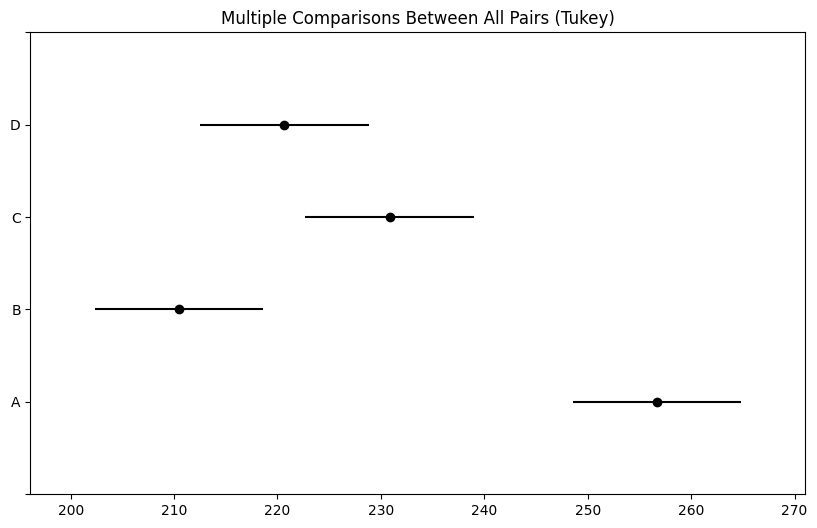

group1,group2,meandiff,p-adj,lower,upper,reject
A,B,-46.1667,0.0,-62.4431,-29.8903,True
A,C,-25.8333,0.0013,-42.1097,-9.5569,True
A,D,-36.0,0.0,-52.2764,-19.7236,True
B,C,20.3333,0.0112,4.0569,36.6097,True
B,D,10.1667,0.3263,-6.1097,26.4431,False
C,D,-10.1667,0.3263,-26.4431,6.1097,False


In [13]:
# @title **HSD de Tukey Grafico para la diferencia de Medias**
tukey = pairwise_tukeyhsd(endog=df["Desgaste"],     # Data
                          groups=df["Tipos de Cuero"],   # Groups
                          alpha=0.05)          # Significance level

tukey.plot_simultaneous()    # Plot group confidence intervals
plt.show()

tukey.summary()

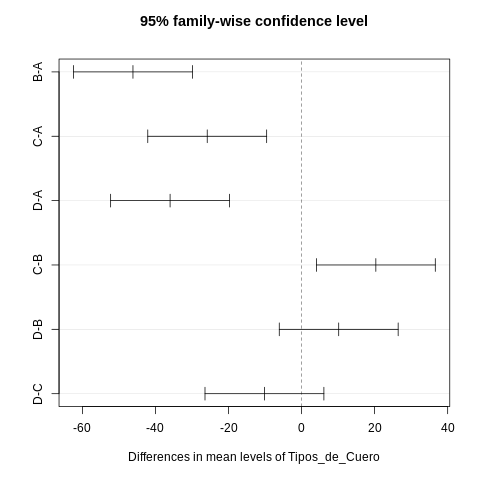

In [23]:
%%R
# @title **HSD de Tukey Grafico para la diferencia de Medias en R**
# Plot the Tukey HSD results
plot(tukey_result_r)

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. HSD de Tukey Grafico Vertical para la diferencia de Medias**




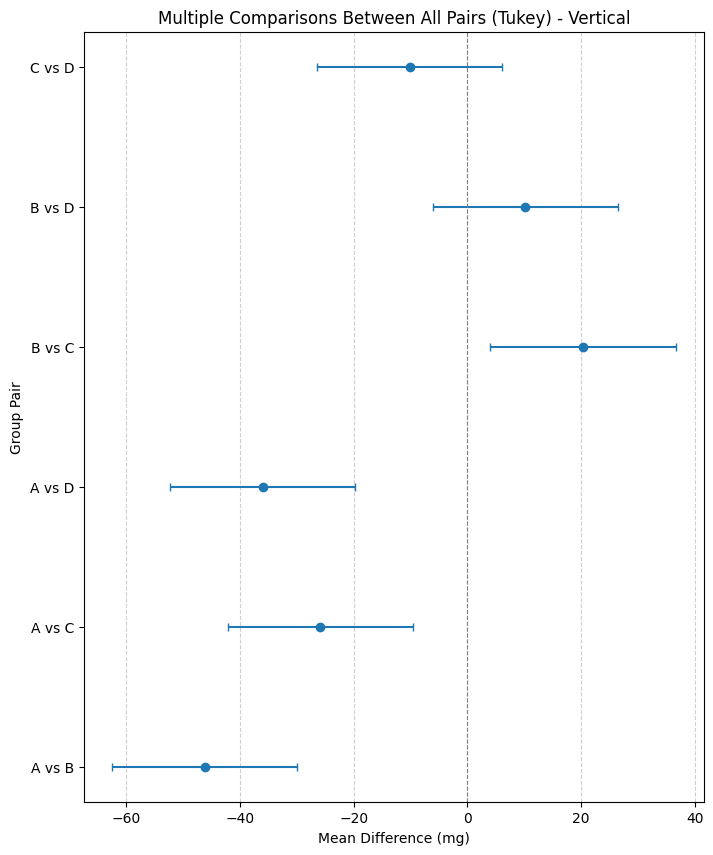

In [14]:
# @title **HSD de Tukey Grafico Vertical para la diferencia de Medias**

# Get the data from the Tukey HSD result
tukey_data = pd.DataFrame(tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

# Create a new column for the mean difference and its confidence interval
tukey_data['mean_diff_ci'] = tukey_data.apply(lambda row: f"{row['meandiff']:.2f} ({row['lower']:.2f}, {row['upper']:.2f})", axis=1)

# Create a categorical type for the group pairs to maintain order in the plot
tukey_data['group_pair'] = tukey_data['group1'] + ' vs ' + tukey_data['group2']

# Plotting
plt.figure(figsize=(8, 10)) # Adjust figure size for vertical plot
plt.errorbar(x=tukey_data['meandiff'], y=tukey_data['group_pair'], xerr=[tukey_data['meandiff'] - tukey_data['lower'], tukey_data['upper'] - tukey_data['meandiff']], fmt='o', capsize=3)

# Add a vertical line at 0 for reference
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title('Multiple Comparisons Between All Pairs (Tukey) - Vertical')
plt.xlabel('Mean Difference (mg)')
plt.ylabel('Group Pair')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

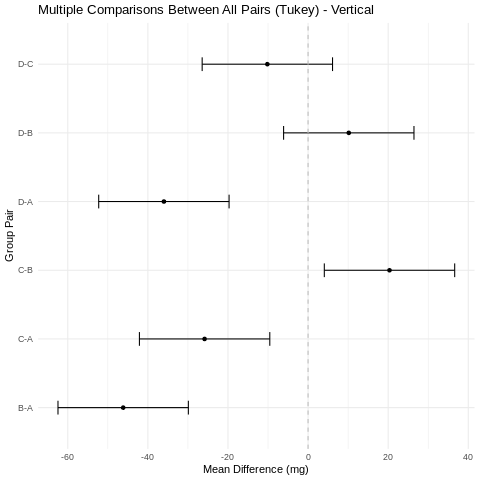

In [24]:
%%R
# @title **HSD de Tukey Grafico Vertical para la diferencia de Medias en R**
library(ggplot2)
library(dplyr)

# Convert Tukey HSD results to a dataframe
tukey_df <- as.data.frame(tukey_result_r$Tipos_de_Cuero)
tukey_df$pair <- rownames(tukey_df)

# Create the vertical plot
ggplot(tukey_df, aes(x = diff, y = pair)) +
  geom_point() +
  geom_errorbarh(aes(xmin = lwr, xmax = upr), height = 0.2) +
  geom_vline(xintercept = 0, color = "grey", linetype = "dashed") +
  labs(title = "Multiple Comparisons Between All Pairs (Tukey) - Vertical",
       x = "Mean Difference (mg)",
       y = "Group Pair") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1)) # Ensure y-axis labels are horizontal

[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Shapiro Wilks para Desgaste en R y Python**


In [25]:
%%R
# @title **11. Shapiro Wilks para Desgaste en R**
# Perform Shapiro-Wilk test on the residuals
shapiro_result <- shapiro.test(residuals(anova_result))

# Print the results
print(paste("El estadistico de Prueba para shapiro wilks w =", shapiro_result$statistic))
print(paste("El valor p para el estadistico de prueba es p_value =", shapiro_result$p.value))
print(paste("Para que se cumpla el supuesto de normalidad se debe cumplir que p_value =", shapiro_result$p.value > 0.05))

[1] "El estadistico de Prueba para shapiro wilks w = 0.878119423905725"
[1] "El valor p para el estadistico de prueba es p_value = 0.0076182402268792"
[1] "Para que se cumpla el supuesto de normalidad se debe cumplir que p_value = FALSE"


In [26]:
# @title **11. Shapiro Wilks para Desgaste en Python**
from scipy import stats

# Perform Shapiro-Wilk test on the residuals
shapiro_result_py = stats.shapiro(modelo_desgaste.resid)
w, p_value = shapiro_result_py

# Print the results
print('El estadistico de Prueba para shapiro wilks w =', w)
print('El valor p para el estadistico de prueba es p_value =', p_value)
print('Para que se cumpla el supuesto de normalidad se debe cumplir que p_value =', p_value > 0.05)

El estadistico de Prueba para shapiro wilks w = 0.8781194237526648
El valor p para el estadistico de prueba es p_value = 0.007618240172874149
Para que se cumpla el supuesto de normalidad se debe cumplir que p_value = False


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


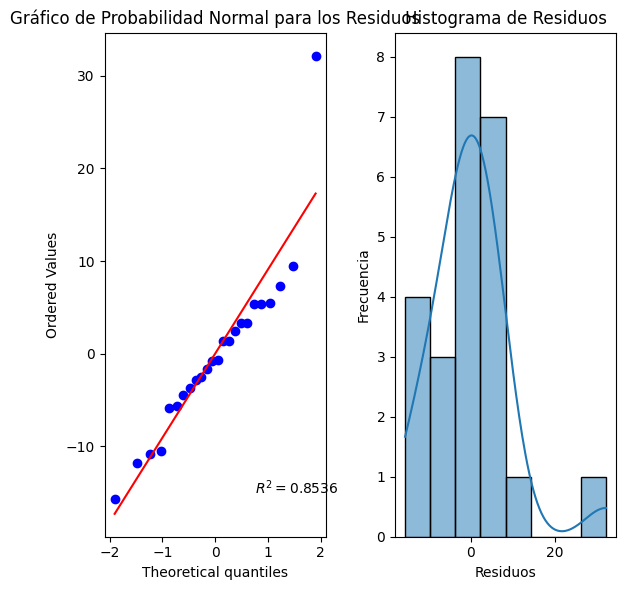

In [27]:
# @title **12. Gráfico de Probabilidad Normal y Histograma para los Residuos en Python**

# Normal Probability Plot
fig = plt.figure(figsize= (6, 6))
ax1 = fig.add_subplot(121)
stats.probplot(modelo_desgaste.resid, plot=ax1, rvalue=True)
ax1.set_title("Gráfico de Probabilidad Normal para los Residuos")

# Histogram of Residuals
ax2 = fig.add_subplot(122)
sns.histplot(modelo_desgaste.resid, kde=True, ax=ax2)
ax2.set_title("Histograma de Residuos")
ax2.set_xlabel("Residuos")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO